In [2]:
# Data Handling Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NLP Libraries
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download Stopwords
nltk.download('stopwords')

print("All Libraries Imported Successfully")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


All Libraries Imported Successfully


In [3]:
# Load Fake News Dataset
fake_df = pd.read_csv('Fake.csv')

# Load Real News Dataset
true_df = pd.read_csv('True.csv')

# Display First 5 Rows
print("FAKE NEWS DATASET")
display(fake_df.head())

print("REAL NEWS DATASET")
display(true_df.head())

FAKE NEWS DATASET


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


REAL NEWS DATASET


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
print("Fake Dataset Shape:", fake_df.shape)
print("Real Dataset Shape:", true_df.shape)

Fake Dataset Shape: (23481, 4)
Real Dataset Shape: (21417, 4)


In [5]:
# Add Label Column

fake_df['label'] = 0
true_df['label'] = 1

print("Fake Dataset")
display(fake_df.head())

print("Real Dataset")
display(true_df.head())

Fake Dataset


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Real Dataset


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [6]:
# Combine Fake and Real Datasets

data = pd.concat([fake_df, true_df], axis=0)

# Shuffle Dataset
data = data.sample(frac=1)

# Reset Index
data.reset_index(inplace=True)

print("Combined Dataset")
display(data.head())

Combined Dataset


,index,title,text,subject,date,label
0,18447,"Israel sees Assad winning Syria war, urges mor...",JERUSALEM (Reuters) - Israel s defense ministe...,worldnews,"October 3, 2017",1
1,2854,Trump Targets Clean Water And Clean Air Regul...,It s official. Donald Trump is literally tryin...,News,"January 25, 2017",0
2,20900,"About 146,000 Rohingya have fled Myanmar viole...","YANGON (Reuters) - About 146,000 Rohingya Musl...",worldnews,"September 6, 2017",1
3,11524,"U.N. hails first step on Syria detainees, caut...",GENEVA (Reuters) - U.N. Syria envoy Staffan de...,worldnews,"December 22, 2017",1
4,22590,BOILER ROOM – EP #52 – Never Ending Chaos,Tune in to the Alternate Current Radio Network...,US_News,"April 13, 2016",0


In [7]:
print("Final Dataset Shape:", data.shape)

print("\nLabel Counts:")
print(data['label'].value_counts())

Final Dataset Shape: (44898, 6)

Label Counts:
label
0    23481
1    21417
Name: count, dtype: int64


In [8]:
# Check Missing Values

print(data.isnull().sum())

index      0
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [9]:
# Remove Missing Values

data = data.dropna()

print("Missing Values Removed Successfully")

Missing Values Removed Successfully


In [10]:
# Remove Duplicate Records

data = data.drop_duplicates()

print("Duplicate Rows Removed Successfully")

Duplicate Rows Removed Successfully


In [11]:
# Combine Title and Text

data['content'] = data['title'] + " " + data['text']

print(data[['content']].head())

                                             content
0  Israel sees Assad winning Syria war, urges mor...
1   Trump Targets Clean Water And Clean Air Regul...
2  About 146,000 Rohingya have fled Myanmar viole...
3  U.N. hails first step on Syria detainees, caut...
4  BOILER ROOM – EP #52 – Never Ending Chaos Tune...


In [12]:
# Initialize Stopwords and Stemmer

stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

print("Stopwords and Stemmer Ready")

Stopwords and Stemmer Ready


In [13]:
# Text Cleaning Function

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove text inside brackets
    text = re.sub(r'\[.*?\]', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)

    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # Remove newlines
    text = re.sub(r'\n', '', text)

    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply stemming
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            stemmed_word = stemmer.stem(word)
            cleaned_words.append(stemmed_word)

    # Join words back into sentence
    return " ".join(cleaned_words)

In [15]:
# Apply Cleaning Function

data['content'] = data['content'].apply(clean_text)

print("Text Cleaning Completed Successfully")

Text Cleaning Completed Successfully


In [16]:
# Display Cleaned Content

print(data['content'].head())

0    israel see assad win syria war urg us involv j...
1    trump target clean water clean air regul envir...
2    rohingya fled myanmar violenc bangladesh yango...
3    un hail first step syria detain cautiou sochi ...
4    boiler room – ep – never end chao tune altern ...
Name: content, dtype: object


In [17]:
print("Final Dataset Shape After Cleaning:", data.shape)

Final Dataset Shape After Cleaning: (44898, 7)


In [18]:
# Input Features

X = data['content']

# Output Labels

y = data['label']

print("Input and Output Variables Created Successfully")

Input and Output Variables Created Successfully


In [19]:
# Create TF-IDF Vectorizer

vectorizer = TfidfVectorizer(max_features=5000)

# Transform Text Data into Numerical Form

X_vectorized = vectorizer.fit_transform(X)

print("TF-IDF Vectorization Completed")

TF-IDF Vectorization Completed


In [20]:
print("Shape of Vectorized Data:", X_vectorized.shape)

Shape of Vectorized Data: (44898, 5000)


In [21]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

print("Training and Testing Data Created")

Training and Testing Data Created


In [22]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (35918, 5000)
Testing Data Shape: (8980, 5000)


In [23]:
# Create Logistic Regression Model

model = LogisticRegression()

print("Model Created Successfully")

Model Created Successfully


In [24]:
# Train Model

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [25]:
# Predict on Test Data

y_pred = model.predict(X_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [26]:
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 1 1 0 1 0 1 0 0 1]


In [31]:
# Custom News Prediction Function

def predict_news(news):

    # Clean Input Text
    cleaned_news = clean_text(news)

    # Convert to TF-IDF
    vectorized_news = vectorizer.transform([cleaned_news])

    # Predict
    prediction = model.predict(vectorized_news)

    # Output Result
    if prediction[0] == 0:
        return "Fake News"
    else:
        return "Real News"

In [32]:
sample_news = """
Scientists confirm that aliens have officially landed in New York City.
"""

result = predict_news(sample_news)

print("Prediction:", result)

Prediction: Fake News


In [33]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.989532293986637


In [34]:
accuracy_percentage = accuracy * 100

print("Accuracy Percentage:", round(accuracy_percentage, 2), "%")

Accuracy Percentage: 98.95 %


In [35]:
# Classification Report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4657
           1       0.99      0.99      0.99      4323

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [36]:
# Create Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4597   60]
 [  34 4289]]


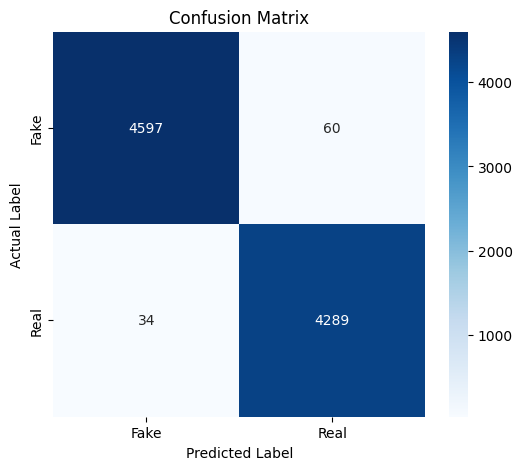

In [37]:
# Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

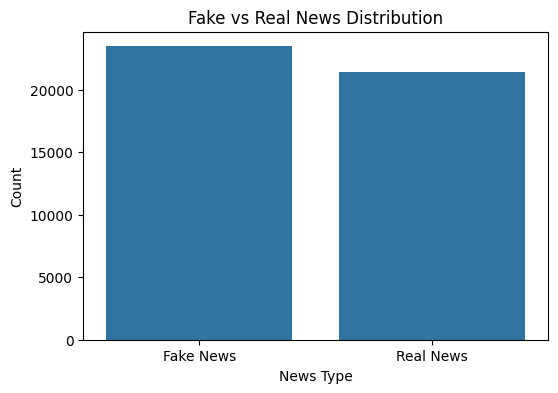

In [38]:
# Label Distribution Graph

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=data)

plt.xticks([0,1], ['Fake News', 'Real News'])

plt.title("Fake vs Real News Distribution")

plt.xlabel("News Type")
plt.ylabel("Count")

plt.show()

In [39]:
import pickle

# Save trained model
with open('fake_news_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully
